# 1. d2

Correlation sum, correlation dimension and order-2 Renyi entropy with
`nolitisea.dimension.d2.d2`.

For every embedding order `m = 1 .. n_vars * embed` the correlation
sum

    C2(m, eps) = #{pairs with Chebyshev distance <= eps} / norm

is evaluated on a geometric ladder of radii.  The input may be 1-D (a
single series) or 2-D of shape `(n_times, n_vars)` with one column
per component.  Pairs whose time separation is at most `theiler` are
excluded from both the counts and the normalisation.

The result contains the radii `eps`, the correlation sums `c2`, the
local slopes `d2` (correlation-dimension estimates) and the order-2
Renyi entropy estimates `h2`.

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from nolitisea.dimension.d2 import d2
from nolitisea.generate.lorenz import lorenz

# Lorenz x component: the correlation dimension is about 2.05.
np.random.seed(0)
_, data = lorenz(length=2000)
x = data[:, 0]

res = d2(
    x,
    embed=8,     # maximum embedding dimension
    delay=5,     # time delay
    theiler=50,  # exclude temporally correlated pairs
    howoften=40, # number of radii on the ladder
)
print(f"eps: {res['eps'].shape}, c2: {res['c2'].shape}, "
      f"d2: {res['d2'].shape}, h2: {res['h2'].shape}")
print(f"eligible pairs (norm): {res['norm']}")

eps: (40,), c2: (8, 40), d2: (8, 39), h2: (8, 40)
eligible pairs (norm): 1832655


## Correlation sums

The log-log plot of `C2` against the radius `eps` shows the scaling
region: with increasing embedding order `m` the curves saturate at
the attractor dimension, so they fan out and flatten.

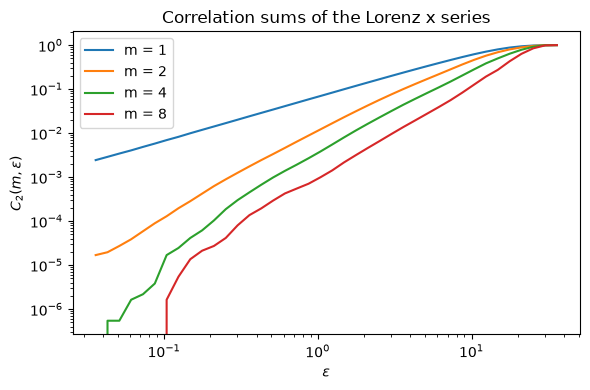

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
dims = [1, 2, 4, 8]  # embedding orders to show
for m in dims:
    ax.loglog(res["eps"], res["c2"][m - 1], label=f"m = {m}")
ax.set_xlabel(r"$\varepsilon$")
ax.set_ylabel(r"$C_2(m, \varepsilon)$")
ax.set_title("Correlation sums of the Lorenz x series")
ax.legend()
plt.tight_layout()
plt.show()

## Correlation dimension

The local slopes of the curves above,

    d2 = d log C2 / d log eps,

approach a plateau for large `m`; its height inside the scaling
region is the correlation-dimension estimate `D2` (about 2.05 for
the Lorenz attractor).  Averaging the slopes of the highest
embedding order over the middle part of the ladder gives a single
number.

D2 estimate (mean slope, m = 8): 2.000 (expected about 2.05)


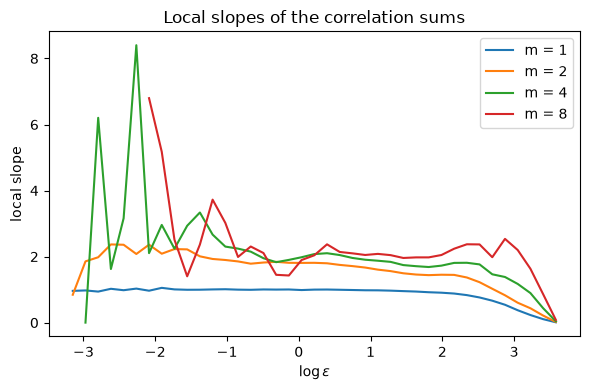

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
log_eps = np.log(res["eps"][:-1])
for m in dims:
    ax.plot(log_eps, res["d2"][m - 1], label=f"m = {m}")
ax.set_xlabel(r"$\log \varepsilon$")
ax.set_ylabel("local slope")
ax.set_title("Local slopes of the correlation sums")
ax.legend()

# Plateau estimate: average slope of the highest order in the
# middle third of the ladder (the scaling region).
slopes = res["d2"][-1]
lo, hi = slopes.size // 3, 2 * slopes.size // 3
estimate = np.nanmean(slopes[lo:hi])
print(f"D2 estimate (mean slope, m = {res['d2'].shape[0]}): "
      f"{estimate:.3f} (expected about 2.05)")

plt.tight_layout()
plt.show()